# CV - Image Classification Lab

Note that this lab has three levels: basic, regular and advanced.


Doing the **basic** part earns you a grade of 5.5-6.0.

Doing the **regular** part earns you a max grade of 8.0.

Doing the **advanced** part earns you a max grade of 10.0.

Please return a Jupyter notebook as a submission in Canvas, this makes grading easier for us.

<font color="red" size="4" face="Arial">As you go through the exercises, you'll encounter various example outputs. Use these as references while navigating the assignment. However, matching these exact values or neural network structures isn't the primary objective. You're encouraged to adjust the parameters as needed, ensuring they remain relevant and appropriate for the task at hand.</font>


## Basic Level
In this part, we will attempt a binary classification problem using a DNN and a CNN.

We will then proceed to change our network architectures to solve a multiclassification problem.

The dataset used consists of medical images of breast cancer using ultrasound scan.

The images are categorized into three classes, which are **normal**, **benign**, and **malignant**.

### Necessary imports

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import os
import os.path
from tqdm import tqdm
from pathlib import Path
from typing import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt
import keras
from keras.utils import to_categorical 
import random
from sklearn.metrics import confusion_matrix
from scipy.special import softmax
from keras.layers import LeakyReLU
from sklearn.utils import shuffle
from keras.layers import  Input, Dense, BatchNormalization, Conv2D
from keras import layers
from keras.layers import Input, Dense, Activation,BatchNormalization, Flatten, Conv2D, MaxPooling2D
from keras.models import Model, Sequential
from keras.preprocessing import image
import keras.backend as K




I0000 00:00:1789045194.240751  383478 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789045194.241375  383478 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789045194.305972  383478 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789045195.297495  383478 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


E0000 00:00:1789045195.398071  383478 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
folder = 'Assignment_Dataset'
rs=1
ts=0.25

### Exercise 1
The directory above contains the dataset for this week's assignment. 

You'll find three folders within it, **normal** ,**malignant** and **benign**.
Load the images within the three folders, with the appropriate labels (the images within the folder **malignant** should be labelled with **malignant**, same goes for **benign** and **normal**).
One way to do this, is to load the images in one list, and load the labels (corresponding to the name of the folder you load the scans from) in another list.

Note also that we're working with a small dataset. 

In [4]:

dataset_path = Path.cwd().parent / "databank" / folder

image_paths = list(dataset_path.glob('**/*.png'))
images = [Image.open(path) for path in image_paths]
label = [path.parent.name for path in image_paths]


In [5]:
print("In all folders, we have", len(images),"images","and ", len(label), "corresponding labels")

In all folders, we have 780 images and  780 corresponding labels


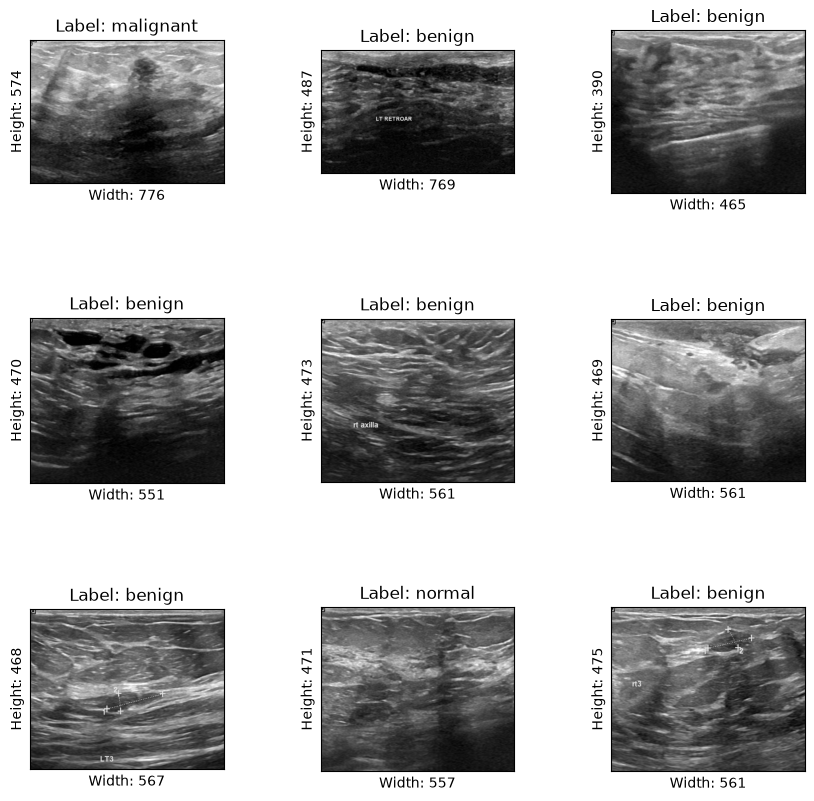

In [6]:
vis_images, vis_label = shuffle(images, label)
plt.figure(figsize=(10, 10))
for i in range(1, 10):  
    plt.subplot(3, 3, i)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.imshow(vis_images[i-1])
    plt.title(f'Label: {vis_label[i-1]}', fontsize=12)
    width, height = vis_images[i-1].size
    plt.xlabel(f'Width: {width}', fontsize=10)
    plt.ylabel(f'Height: {height}', fontsize=10)
    plt.xticks([])
    plt.yticks([])
plt.show()


### Exercise 2
Write a function **convert(dataset, target_mode)** that will take your list of images and convert them from their current mode RGB, to the target mode **L** (grayscale)

In [7]:
print("The current mode of the images in the dataset is",images[0].mode)

The current mode of the images in the dataset is RGB


In [8]:
def convert(dataset, mode: Literal['RGB', 'L']): 
    return [image.convert(mode) for image in dataset]
        

In [9]:
images=convert(images, 'L')

In [10]:
print("Image mode is now",images[0].mode)

Image mode is now L


### Exercise 3
It turns out that the images in our dataset are not of the same size. 
Write a function **check_size(dataset)**, which inputs your dataset of images and returns True if all images are of the same size and False otherwise.

In [11]:
def check_size(dataset):
    check = all(image.size == dataset[0].size for image in dataset)
    return check

In [12]:
print("All images are of the same size:",check_size(images))

All images are of the same size: False


### Exercise 4
Write a function **resize(dataset, size)**, to which you pass your dataset and a tuple (h, w). Your function should output the dataset with all the images in the same size.

In [13]:
def resize(dataset,size):
    dataset = [image.resize(size) for image in dataset]
    return dataset  
    

In [14]:
resized_images=resize(images, (64,64))

In [15]:
print("All images are of the same size:",check_size(resized_images))

All images are of the same size: True


In [16]:
print(type(images[0]))

<class 'PIL.Image.Image'>


### Exercise 5
Recall that a model cannot be trained on an Image object, we need first to convert our dataset of images into a dataset of numpy arrays, in which every array is the representation of an image.

Write a function **to_npArray(dataset)**, which will input your images dataset and return the dataset with the images converted to numpy arrays.

In [17]:
def to_npArray(dataset):
    '''
    TODO: implement this function
    '''
    dataset = [np.array(image) for image in dataset]
    return dataset

In [18]:
np_images=to_npArray(resized_images)

In [19]:
np_images=np.array(np_images)

In [20]:
np_images.shape

(780, 64, 64)

#### You can see now that our dataset has 780 examples, each example is of the shape (h,w). In our case here (64,64). Feel free to resize your images to the values you see fit. Keep in mind that a higher size means more features, slower training, and a risk of overfitting.

### Exercise 6
Pixel values in our grayscale images might go up to 255, when calculating sigmoid of such values (multiplied by their respective weights), we might end up with overflow issues.
One way to solve this problem is by feature scaling.
You can use sklearn's [MixMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) to scale the features in your dataset. You can also implement your own scaler, by simply dividing all the values in your dataset by the max value.

In [21]:
#Your code goes here

print(f"Before scaling : Min={np.min(np_images)}, Max={np.max(np_images)}")
scaler = MinMaxScaler()
np_images_scaled = scaler.fit_transform(np_images.reshape(-1, np_images.shape[-1])).reshape(np_images.shape)

print(f"After scaling : Min={np.min(np_images_scaled)}, Max={np.max(np_images_scaled)}")


Before scaling : Min=0, Max=255
After scaling : Min=0.0, Max=1.0


## Binary classification 
We'll start by doing a binary classification problem.

In later exercises, we will shift back to treating the multiclassification problem the dataset suggests.
### Exercise 7

We are now preparing our dataset for binary classification. While our dataset contains three classes - **benign**, **malignant**, and **normal** - our initial model will categorize the scans as either **0** (malignant) or **1** (either normal or benign). We'll formulate a 'y' vector where the '**malignant**' label is encoded as **0**, and the other labels are encoded as **1**.


In [22]:
#Your code goes here

y = np.array([0 if lbl == 'malignant' else 1 for lbl in label])

### Exercise 8

For this task, you'll employ **Keras** to construct your neural network. We've shown in the lecture how straightforward it is to design DNNs with Keras: all you need to do is outline your network's structure and let Keras do the heavy lifting.

The lecture's demonstration assumes that images have been flattened before they are fed into the Keras DNN. This means the dataset will have a shape like (ne, w, h). Given our dataset with **780 samples** and an image size of (64 , 64), when you flatten these images, they will reshape the dataset to (780, 4096).

Keras can also handle the flattening for you. So, you can supply the dataset in the shape (780, 64, 64) and Keras will take care of reshaping before starting the model's training.

a. Reshape your dataset to what Keras expects

In [23]:
#Your code goes here

np_images_flattened = np_images_scaled.reshape(len(np_images_scaled), -1)


In [24]:
np_images_flattened.shape

(780, 4096)

In [25]:
train_X, test_X, train_y, test_y = train_test_split(np_images_flattened, y, test_size=ts, shuffle=True, random_state=rs)

b. Create your model and compile it in the cell below

In [26]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(4096,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['acc']
)


/home/tonso/code/ptonso/course/ut/ds-ai/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,049 (4.16 MB)

 Trainable params: 1,090,049 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

c. Fit the model to the data below

In [28]:


history = model.fit(
    train_X,
    train_y,
    epochs=250,
    validation_data=(test_X, test_y)
)


Epoch 1/250
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.7077 - loss: 0.6257 - val_acc: 0.7128 - val_loss: 0.5846
Epoch 2/250
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - acc: 0.7915 - loss: 0.4916 - val_acc: 0.7744 - val_loss: 0.5209
Epoch 3/250
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.7829 - loss: 0.4645 - val_acc: 0.8000 - val_loss: 0.4794
Epoch 4/250
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.8000 - loss: 0.4387 - val_acc: 0.7795 - val_loss: 0.5042
Epoch 5/250
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.8205 - loss: 0.4270 - val_acc: 0.7795 - val_loss: 0.4962
Epoch 6/250
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.8359 - loss: 0.3962 - val_acc: 0.8359 - val_loss: 0.4827
Epoch 7/250
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.8325 - loss: 0.4120 - val_acc: 0.7692 - val_loss: 0.4878
Epoch 8/250
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.8205 - loss: 0.4341 - val_acc: 0.8154 - val_loss: 0.4625
Epoch 9/250
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - ac

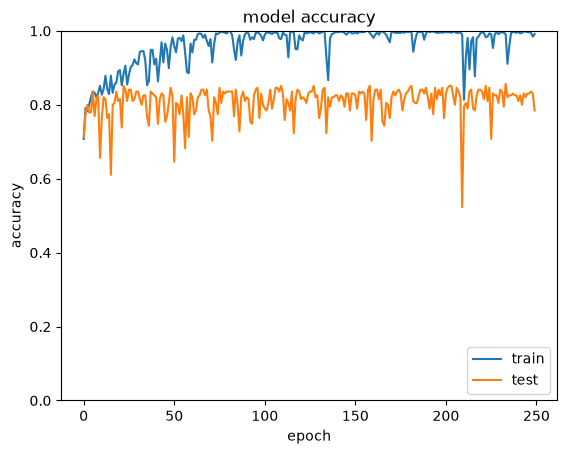

In [29]:
# visualise training history
plt.plot(model.history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.ylim(0, 1)
plt.show()

d. Print the accuracy of your model on the train and test set

In [30]:
print(f"Accuracy of the model on the train set is {model.history.history['acc'][-1]*100} %")
print(f"Accuracy of the model on the test set is {model.history.history['val_acc'][-1]*100} %")

Accuracy of the model on the train set is 99.14529919624329 %
Accuracy of the model on the test set is 78.46153974533081 %


e. Update (by simply rerunning the cell) the confusion matrix below to check how good your model has done on the data.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


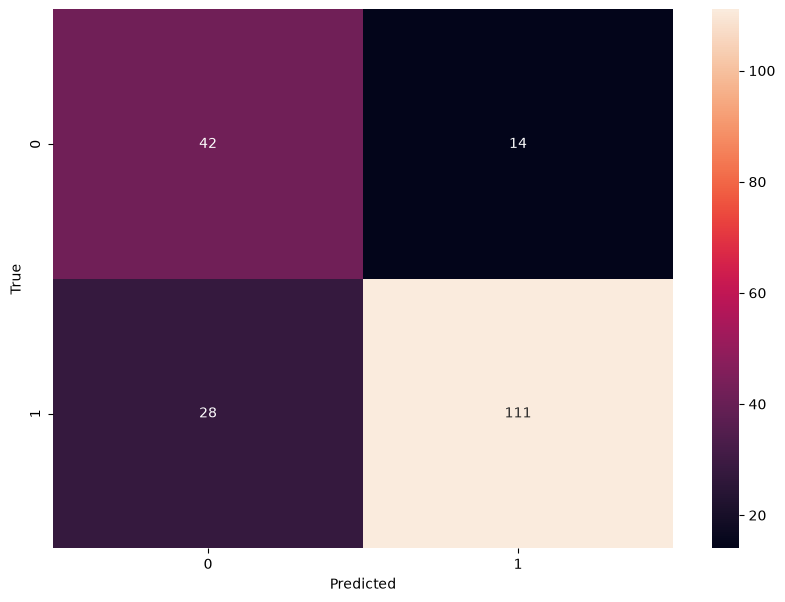

In [31]:
predictions = model.predict(test_X)
predicted_labels = (predictions > 0.5).astype("int32")
cm = confusion_matrix(test_y, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Exercise 9
Let's now try the same thing with a CNN and see whether we can improve on the results we get.
You're free to try any CNN architecture you wish. Keep in mind that a high number of layers and of filters in these layers makes the number of parameters grow, and makes the learning duration longer.

In [32]:
train_X, test_X, train_y, test_y = train_test_split(np_images, y, test_size=ts, shuffle=True, random_state=rs)

a. Create and compile your model architecture below

In [33]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(64, 64, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

b. Fit your CNN to the data

In [35]:
history = model.fit(
    train_X,
    train_y,
    epochs=100,
    validation_data=(test_X, test_y)
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.6068 - loss: 6.3906 - val_accuracy: 0.7385 - val_loss: 0.5645
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.7829 - loss: 0.5076 - val_accuracy: 0.7231 - val_loss: 0.5845
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7761 - loss: 0.4551 - val_accuracy: 0.7590 - val_loss: 0.4716
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8274 - loss: 0.3890 - val_accuracy: 0.8205 - val_loss: 0.4200
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8615 - loss: 0.3234 - val_accuracy: 0.8359 - val_loss: 0.4318
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8991 - loss: 0.2481 - val_accuracy: 0.8359 - val_loss: 0.3980
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9179 - loss: 0.2120 - val_accuracy: 0.8410 - val_loss: 0.3893
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9060 - loss: 0.2234 - val_accuracy: 0.

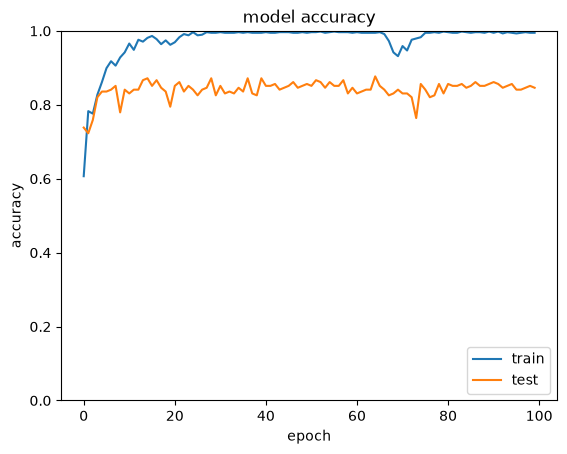

In [36]:
# visualise training history
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0, 1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

c. Print your model's accuracy on the test and train sets

In [37]:
print(f"Accuracy of the model on the train set is {model.history.history['accuracy'][-1]*100:.2f} %")
print(f"Accuracy of the model on the test set is {model.history.history['val_accuracy'][-1]*100:.2f} %")

Accuracy of the model on the train set is 99.49 %
Accuracy of the model on the test set is 84.62 %


d. Create a confusion matrix to inspect the model's output

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


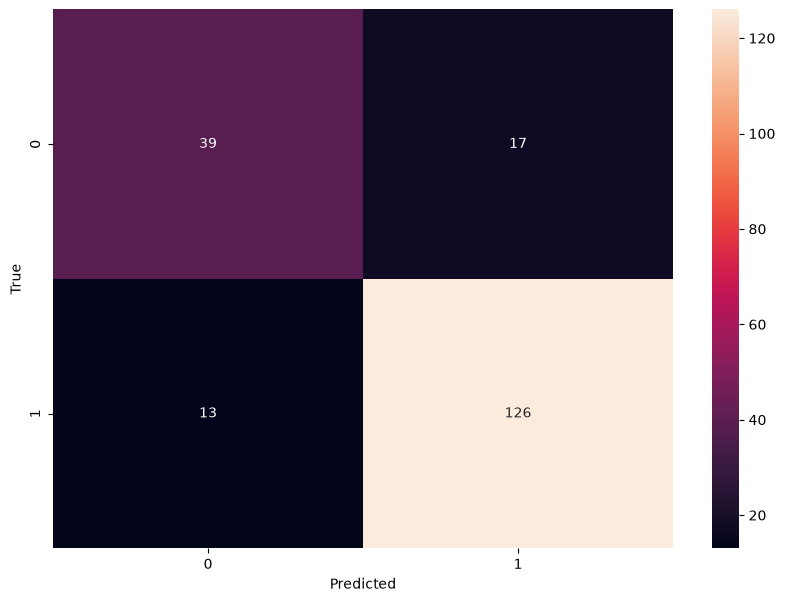

In [38]:
predictions = model.predict(test_X)
predicted_labels = (predictions > 0.5).astype("int32")
cm = confusion_matrix(test_y, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Turns out my CNN architecture underperforms against my DNN. Depending on how your CNNs architecture and parameters are, you might get better results.

## Multiclassification
Let's now shift back to building models that can distinguish the three classes, and not just segregate the **normal** scans from the other scans.

Our first task is to encode our **y** vector properly. 
Keep also in mind that the **sigmoid** activation is not the right choice for the output layer, and that the number of neurons of the output layer needs to be equal to the number of expected classes.

### Exercise 10
Create a **y** matrix for your labels. The **y** matrix is of shape **(ne, nc)**. 

With **ne** meaning number of examples and **nc** meaning number of possible classes.

Refer to keras' to_categorical() function to create your ground truth matrix.

In [39]:
label_map = {'benign': 0, 'malignant': 1, 'normal': 2}
y = to_categorical([label_map[lbl] for lbl in label], num_classes=3)

In [40]:
y.shape

(780, 3)

### Exercise 11


In [41]:
train_X, test_X, train_y, test_y = train_test_split(np_images_flattened, y, test_size=ts, shuffle=True, random_state=rs)

a. You can now create another DNN to classify your scans according to their labels.

In [42]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout

model = Sequential([
    Input(shape=(4096,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,179 (4.16 MB)

 Trainable params: 1,090,179 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

b. Train your model below

In [44]:
history = model.fit(
    train_X,
    train_y,
    epochs=100,
    validation_data=(test_X, test_y)
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4940 - loss: 1.1834 - val_accuracy: 0.5385 - val_loss: 0.9917
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4786 - loss: 1.0871 - val_accuracy: 0.6205 - val_loss: 0.9376
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5607 - loss: 1.0008 - val_accuracy: 0.5795 - val_loss: 0.9480
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5504 - loss: 0.9776 - val_accuracy: 0.6154 - val_loss: 0.9309
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5846 - loss: 0.9612 - val_accuracy: 0.6000 - val_loss: 0.9156
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5897 - loss: 0.9423 - val_accuracy: 0.6308 - val_loss: 0.9039
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5966 - loss: 0.9253 - val_accuracy: 0.6359 - val_loss: 0.9050
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6239 - loss: 0.8955 - val_accuracy: 0.

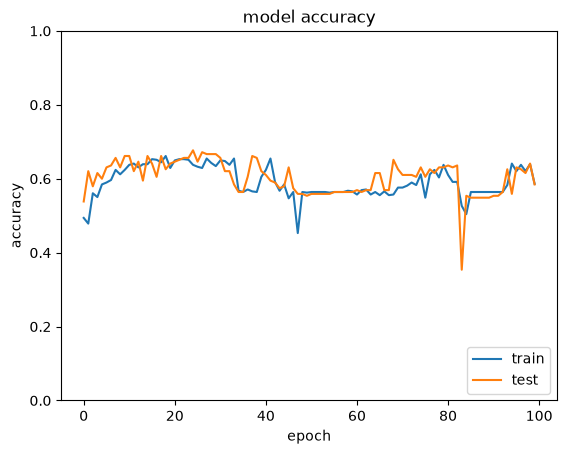

In [45]:
# visualise training history
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

The use of the dropout layers did not prevent the model from memorizing the data. 

The network architecture I used is complex and the training dataset is too small.

c. Print your model's accuracy on the test and train sets

In [46]:
print(f"Accuracy of the model on the train set is {model.history.history['accuracy'][-1]*100:.2f} %")
print(f"Accuracy of the model on the test set is {model.history.history['val_accuracy'][-1]*100:.2f} %")

Accuracy of the model on the train set is 58.63 %
Accuracy of the model on the test set is 58.46 %


d. Create a confusion matrix to inspect the model's output

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


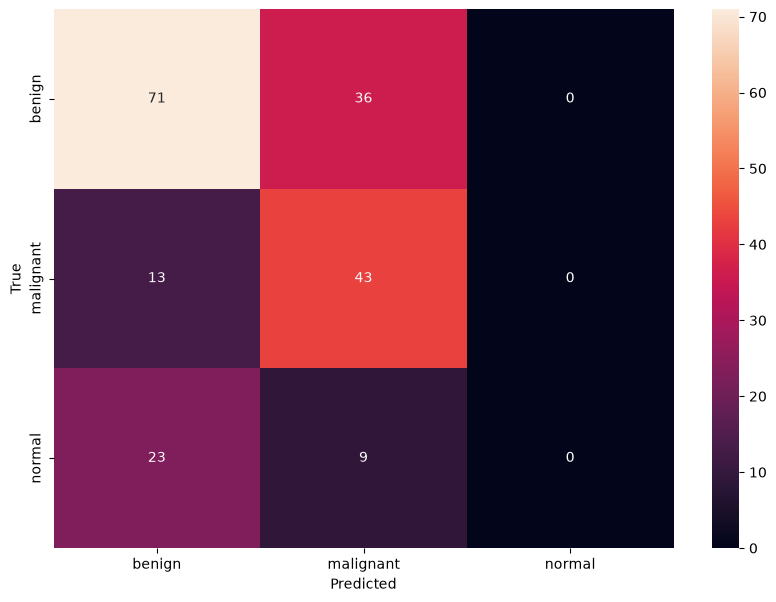

In [47]:
predictions = model.predict(test_X)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_y, axis=1)
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=['benign', 'malignant', 'normal'], yticklabels=['benign', 'malignant', 'normal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Exercise 12
Use Keras again to build and train a new CNN to classify the scans into three the three classes.

In [48]:
train_X, test_X, train_y, test_y = train_test_split(np_images, y, test_size=ts, shuffle=True, random_state=rs)

a. Create your CNN's architecture and compile it

In [49]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(64, 64, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

b. Fit your model to the data

In [50]:
history = model.fit(
    train_X,
    train_y,
    epochs=100,
    validation_data=(test_X, test_y)
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.4444 - loss: 8.6685 - val_accuracy: 0.5744 - val_loss: 0.9648
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.5915 - loss: 0.9231 - val_accuracy: 0.6564 - val_loss: 0.8791
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.6513 - loss: 0.8079 - val_accuracy: 0.6615 - val_loss: 0.7755
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.6701 - loss: 0.7194 - val_accuracy: 0.6410 - val_loss: 0.7728
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.7282 - loss: 0.6347 - val_accuracy: 0.6667 - val_loss: 0.7253
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.7607 - loss: 0.5472 - val_accuracy: 0.6564 - val_loss: 0.7933
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.7692 - loss: 0.5459 - val_accuracy: 0.7385 - val_loss: 0.7786
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8051 - loss: 0.4477 - val_accura

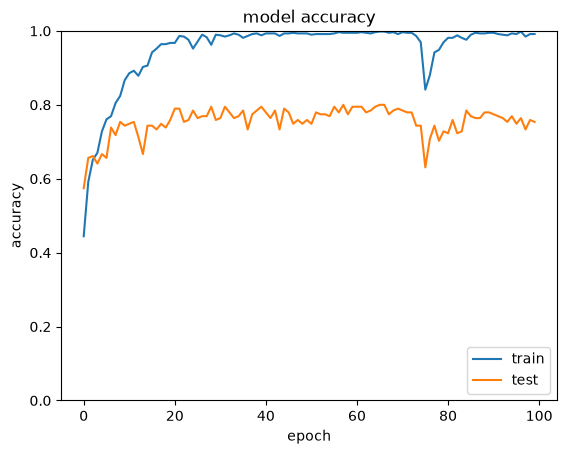

In [51]:
# visualise training history
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

Same overfitting pattern exhibited by the CNN architecture and parameters I used.

c. Check the performance of your model

In [52]:
print(f"Accuracy of the model on the train set is {model.history.history['accuracy'][-1]*100:.2f} %")
print(f"Accuracy of the model on the test set is {model.history.history['val_accuracy'][-1]*100:.2f} %")

Accuracy of the model on the train set is 99.15 %
Accuracy of the model on the test set is 75.38 %


d. Create a confusion matrix to inspect the model's output

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


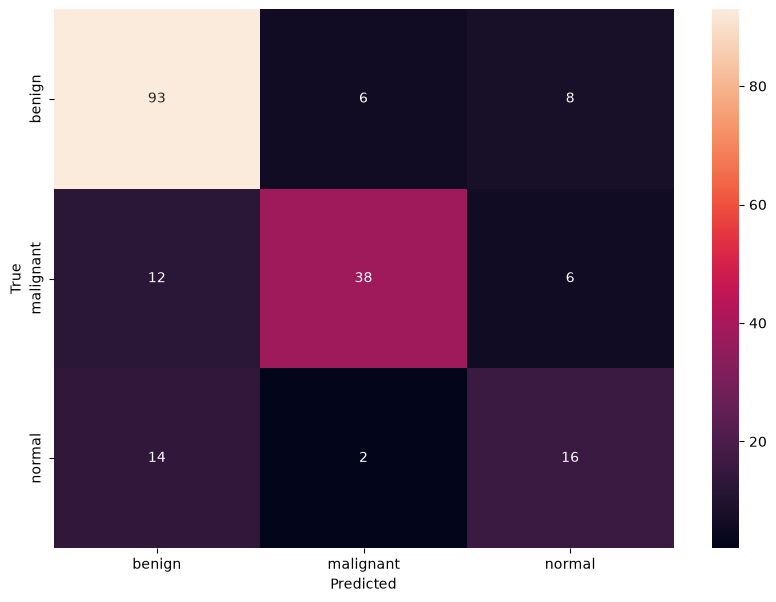

In [53]:
predictions = model.predict(test_X)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_y, axis=1)
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=['benign', 'malignant', 'normal'], yticklabels=['benign', 'malignant', 'normal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Optional Exercise
Both models for multiclassification overfit. This can be caused by the high complexity of the networks that we have used, it could also be due to the low number of training examples we have (around 600 used for training+ an imbalanced dataset).

Refer to this data augmentation technique suggested by Keras [Image Data Generator](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator), and check whether it can help bridge the gap between the accuracy in training and the accuracy of the test set.


In [54]:
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

train_X_exp = np.expand_dims(train_X, axis=-1) if train_X.ndim == 3 else train_X
test_X_exp = np.expand_dims(test_X, axis=-1) if test_X.ndim == 3 else test_X

datagen.fit(train_X_exp)

history_aug = model.fit(
    datagen.flow(train_X_exp, train_y, batch_size=32),
    epochs=100,
    validation_data=(test_X_exp, test_y)
)

ImportError: cannot import name 'ImageDataGenerator' from 'keras.preprocessing.image' (/home/tonso/code/ptonso/course/ut/ds-ai/venv/lib/python3.12/site-packages/keras/preprocessing/image/__init__.py)

### Regular Level
In this part, we wish to implement our own deep learning network for binary classification.
### Exercise 13
To test the functions, let's use a network of the dimensions [64 x 64, 128,64,1]

We'll first write the function initialize(network_dims), which will initialize the weights and biases of our network.

a. Copy your **y** vector of binary classification (not the one hot-encoded matrix)

In [ ]:
#Your code goes here

y = np.array([0 if lbl == 'malignant' else 1 for lbl in label])

In [ ]:
train_X, test_X, train_y, test_y = train_test_split(np_images_flattened, y, test_size=ts, shuffle=True, random_state=rs)

In [ ]:
def initialize(network_dims):
    
    params = {}
    L = len(network_dims)
    for l in range(1, L):
        params['W' + str(l)] = np.random.randn(network_dims[l], network_dims[l - 1])
        params['b' + str(l)] = np.random.randn(network_dims[l], 1)

    return params

In [ ]:
params=initialize([train_X.shape[1], 128,64, 1])

In [ ]:
print('shape of W1', params['W1'].shape)
print('shape of b1', params['b1'].shape)
print('shape of W2', params['W2'].shape)
print('shape of b2', params['b2'].shape)
print('shape of W3', params['W3'].shape)
print('shape of b3', params['b3'].shape)

You are now requested to implement the forward_pass(X, params), which takes your training set X as input and returns the activations of the hidden and final layer.
Your function should implement the following functions:

$$Z^{[l]}=W^{[l]}.A^{[l-1]}+b^{[l]}$$
$$A^{[l]}=\sigma Z^{[l]}$$

You of course need to iterate over the layers of your model (hidden and final/output layer).


In [ ]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def forward_pass(X, params):

    L = len(params) // 2
    activations = {'A0': X}
    A = X
    for l in range(1, L + 1):
        Z = params['W' + str(l)].dot(A) + params['b' + str(l)]
        A = sigmoid(Z)
        activations['A' + str(l)] = A

    return activations

In [ ]:
#recall that X in our scenario is of shape (nf, ne)
train_X=train_X.T

In [ ]:
activations=forward_pass(train_X, params)

In [ ]:
print("The shape of the activation of the first layer",activations['A1'].shape)
print("The shape of the activation of the second layer",activations['A2'].shape)
print("The shape of the activation of the output layer",activations['A3'].shape)

### Exercise 14
We get now to implementing our gradient descent.

Write a function gradient_descent(params, activations, y, lr), which input your parameters, the activations of your forward_pass, your ground truth vector y and your learning_rate lr. 

The function needs to implement the following equations:

$$dZ^{[fl]}=A^{[fl]}-y$$
$$dZ^{[l-1]}=W^{[l]}T .dZ^{[l]} * A^{[l-1]}(1-A^{[l-1]})$$
$$dW^{[l]}=\frac {1}{ne} (dZ^{[l]}.A^{[l-1]}T)$$
$$dW^{[l]}=\frac {1}{ne} \sum dZ^{[l]} $$
$$W=W-\alpha dW$$

$$W=b-\alpha db$$



In [ ]:
def gradient_descent(activations, params, y, lr):

    L = len(params) // 2
    ne = y.shape[0]
    y = y.reshape(1, ne)

    dZ = activations['A' + str(L)] - y

    for l in range(L, 0, -1):
        A_prev = activations['A' + str(l - 1)]

        dW = (1 / ne) * dZ.dot(A_prev.T)
        db = (1 / ne) * np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            dZ = params['W' + str(l)].T.dot(dZ) * A_prev * (1 - A_prev)

        params['W' + str(l)] = params['W' + str(l)] - lr * dW
        params['b' + str(l)] = params['b' + str(l)] - lr * db

    return params

In [ ]:
params=gradient_descent(activations, params, train_y, lr=0.5)

In [ ]:
print('shape of W1', params['W1'].shape)
print('shape of b1', params['b1'].shape)
print('shape of W2', params['W2'].shape)
print('shape of b2', params['b2'].shape)
print('shape of W3', params['W3'].shape)
print('shape of b3', params['b3'].shape)

### Exercise 15
Now we can implement our dnn model in 3 simple steps
1. initialize the matrices W and the bias vectors b
2. repeat until number of iterations is reached 
    2.1. get your matrices of activations
    2.2. update the weights W and biases b using gradient descent
3. return the final matrices for  W and bias vectors b

dnn(X, y, network_dims, lr, iters), takes the matrix X as an input, the vector of true labels y, network dimensions, a learning rate, and the number of iterations iters. The function returns the learned parameters of the model, namely W and b.


In [ ]:
def dnn(X, y, network_dims, lr, iters):

    params = initialize(network_dims)

    for i in range(iters):
        activations = forward_pass(X, params)
        params = gradient_descent(activations, params, y, lr)

    return params

In [ ]:
params=dnn(train_X, train_y, network_dims = [train_X.shape[0], 64, 32,1 ], lr = 0.75, iters = 50)

In [ ]:
def predict(X, params):
    activations = forward_pass(X, params)
    L = len(params) // 2
    Af = activations['A' + str(L)]
    return  1*(Af>=0.5)

In [ ]:
predictions=predict(test_X.T, params)

In [ ]:
print("Accuracy on our test set is", accuracy_score(test_y.flatten(), predictions.flatten())*100, "%")

#### Quite a good result actually.

## Advanced Level
We said in the lecture that a sigmoid activated neurone predicts values between 0 and 1, making it adequate for binary classification.

We also said that a softmax activation function is suitable for multiclassification.
To change our code above and make it capable of doing multiclassification, we need to implement the softmax function.
We also said that the log_loss isn't useful in this case, we will instead use cross entropy loss.

We also said that **dZL** (L for final layer) remains the same as before.

Your task is to modify the code you implemented above to handle the same multiclassification problem you handled with Keras.

We are not interested in a completely new implementation, we expect that you will modify one of your functions above and adapt the code to handle the new type of classification (multiclass).

In [ ]:
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def forward_pass_multiclassification(X, params):
    # Same as forward_pass, except the final layer uses softmax instead of sigmoid
    L = len(params) // 2
    activations = {'A0': X}
    A = X
    for l in range(1, L):
        Z = params['W' + str(l)].dot(A) + params['b' + str(l)]
        A = sigmoid(Z)
        activations['A' + str(l)] = A

    Z = params['W' + str(L)].dot(A) + params['b' + str(L)]
    A = softmax(Z)
    activations['A' + str(L)] = A

    return activations

def gradient_descent_multiclass(activations, params, y, lr):
    # dZ of the final layer is still (A_final - y), as with sigmoid+binary cross-entropy
    L = len(params) // 2
    ne = y.shape[1]

    dZ = activations['A' + str(L)] - y

    for l in range(L, 0, -1):
        A_prev = activations['A' + str(l - 1)]

        dW = (1 / ne) * dZ.dot(A_prev.T)
        db = (1 / ne) * np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            dZ = params['W' + str(l)].T.dot(dZ) * A_prev * (1 - A_prev)

        params['W' + str(l)] = params['W' + str(l)] - lr * dW
        params['b' + str(l)] = params['b' + str(l)] - lr * db

    return params

In [ ]:
def dnn_2(X, y, network_dims, lr, iters):

    params = initialize(network_dims)

    for i in range(iters):
        activations = forward_pass_multiclassification(X, params)
        params = gradient_descent_multiclass(activations, params, y, lr)

    return params

In [ ]:
#Reuse your one-hot-encoded matrix of ground truth for training

# same random_state/test_size as the split used for train_X/test_X above,
# so the rows line up with the same train/test partition
y_int = np.array([label_map[lbl] for lbl in label])
y_onehot = to_categorical(y_int, num_classes=3)

_, _, train_y, _ = train_test_split(np_images_flattened, y_onehot, test_size=ts, shuffle=True, random_state=rs)
_, _, _, test_y = train_test_split(np_images_flattened, y_int, test_size=ts, shuffle=True, random_state=rs)

In [ ]:
params=dnn_2(train_X, train_y.T, network_dims = [train_X.shape[0], 64,4,3 ], lr = 0.0005, iters = 500)

In [ ]:
def predict(X, params):
    activations = forward_pass_multiclassification(X, params)
    C = len(params) // 2
    Af = activations['A' + str(C)]
    return np.argmax(Af, axis=0) 

In [ ]:
predictions=predict(test_X.T, params )

In [ ]:
print("Accuracy on our test set is", accuracy_score(test_y, predictions)*100, "%")

The performance isn't as strong as the Keras models.

In the advanced CV lecture, you'll explore transfer learning, a technique that enables us to repurpose a pre-trained model for classifying different objects and adapt it to identify cancer scans. This method is especially beneficial when the training dataset is limited, and will allow us to improve the accuracy of our cancer detection model.

#### Hope you enjoyed working with DNNs and CNNs